In [43]:
from collections.abc import Sequence
from json import load
import os
import sys

sys.path.append(os.path.abspath('../src'))

import catboost
from matplotlib.pyplot import imshow, ylabel, xlabel, yticks, xticks,\
                                plot, margins
import numpy as np
import polars as pl
from sklearn.base import BaseEstimator, clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score,\
                            confusion_matrix
from sklearn.tree import DecisionTreeClassifier


from feature_extractor import FeatureExtractor

In [25]:
SEED = 42

In [2]:
train_raw = pl.read_csv('../data/processed/train.csv')
test_raw = pl.read_csv('../data/processed/test.csv')


In [5]:
feature_extractor = FeatureExtractor()

In [8]:
train_X = feature_extractor.fit_transform(
    train_raw.drop('error_type_label'))
train_y = train_raw['error_type_label']


1663it [00:17, 93.98it/s] 


In [12]:
test_X = feature_extractor.transform(
    test_raw.drop('error_type_label'))
test_y = test_raw['error_type_label']


835it [00:08, 94.29it/s] 


In [18]:
error_type_ids_file = open('../data/processed/error_type_ids.json',
                        'r', -1, 'utf-8')
error_type_ids = load(error_type_ids_file)
error_type_ids_to_names: list[str] = [''] * 8
for k, v in error_type_ids.items():
    error_type_ids_to_names[v] = k


In [86]:
def evaluate(model: BaseEstimator,
    train: tuple[pl.DataFrame, pl.Series] = (train_X, train_y),
    test: tuple[pl.DataFrame, pl.Series] = (test_X, test_y),
    error_type_ids_to_names: list[str] = error_type_ids_to_names):

    test_X, test_y = test
    classes_present: set[int] = set(test_y.unique().to_list())

    classes_present_names: list[str] = [error_type_ids_to_names[i]
                                        for i in classes_present]
    
    number_of_classes: int = len(classes_present)

    f1 = np.zeros(number_of_classes)
    precision = f1.copy()
    recall = f1.copy()
    confusion_matrix_ = np.zeros((number_of_classes, 
                                   number_of_classes))
    
    train_X, train_y = train
    model.fit(train_X, train_y)
    predictions = model.predict(test_X)

    # теперь просто для каждого класса
    precision = precision_score(test_y, predictions,
                                            average=None,
                                            zero_division=np.nan)
    recall = recall_score(test_y, predictions, average=None,
                                            zero_division=np.nan)
    f1 = f1_score(test_y, predictions, average=None,
                                            zero_division=np.nan)
    confusion_matrix_ = confusion_matrix(test_y, predictions,
                                            normalize='true')
    
    np.set_printoptions(suppress=True)

    print('Класс\t\t\tPrecision\tRecall\t\tF1')
    print(*('%s%.2f\t\t%.2f\t\t%.2f' % (f'{name:<24}',
            precision_.item(),
            recall_.item(),
            f1_.item())
            for name, precision_, recall_, f1_
            in zip(classes_present_names, precision, recall, f1)), 
            sep='\n')
    print('%s%.2f\t\t%.2f\t\t%.2f' % (f'{'По всем':<24}',
            precision[np.logical_not(np.isnan(precision))].mean(),
            recall[np.logical_not(np.isnan(precision))].mean(),
            f1[np.logical_not(np.isnan(precision))].mean()))
    

    imshow(confusion_matrix_)
    ylabel('Истина')
    xlabel('Предсказание')
    yticks(range(number_of_classes), classes_present_names)
    xticks(range(number_of_classes), classes_present_names, 
        rotation=45)

    return f1[np.logical_not(np.isnan(precision))].mean()


Класс			Precision	Recall		F1
нет                     0.94		0.99		0.96
speech arrest           0.83		0.62		0.71
аномия                  0.84		0.68		0.75
дизартрия               0.35		0.16		0.22
задержка                0.68		0.38		0.48
поиск слова             0.55		0.30		0.39
семантическая парафазия 0.56		0.30		0.39
фонетическая парафазия  0.55		0.35		0.43
По всем                 0.66		0.47		0.54


np.float64(0.5432284126592348)

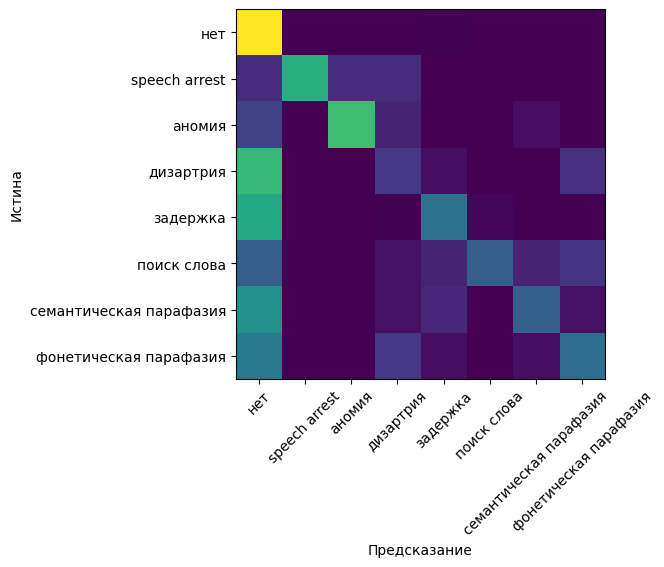

In [33]:
evaluate(DecisionTreeClassifier(max_depth=11, 
                                random_state=SEED))

Класс			Precision	Recall		F1
нет                     0.94		0.96		0.95
speech arrest           0.86		0.75		0.80
аномия                  0.75		0.68		0.71
дизартрия               0.24		0.18		0.21
задержка                0.45		0.41		0.43
поиск слова             0.50		0.45		0.47
семантическая парафазия 0.77		0.37		0.50
фонетическая парафазия  0.49		0.39		0.43
По всем                 0.63		0.52		0.56


np.float64(0.5637197296587619)

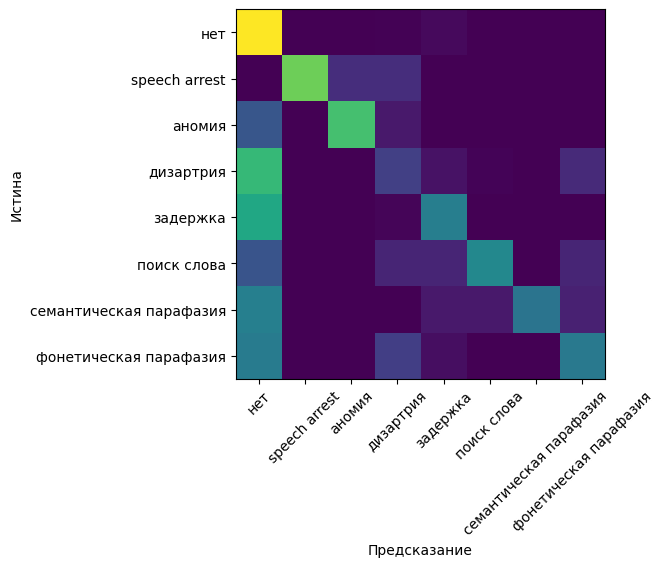

In [35]:
evaluate(RandomForestClassifier(random_state=SEED))


Класс			Precision	Recall		F1
нет                     0.94		0.99		0.97
speech arrest           0.86		0.75		0.80
аномия                  0.81		0.68		0.74
дизартрия               0.52		0.16		0.25
задержка                0.71		0.45		0.55
поиск слова             0.61		0.55		0.58
семантическая парафазия 0.88		0.46		0.60
фонетическая парафазия  0.61		0.39		0.47
По всем                 0.74		0.55		0.62


np.float64(0.6193530081421158)

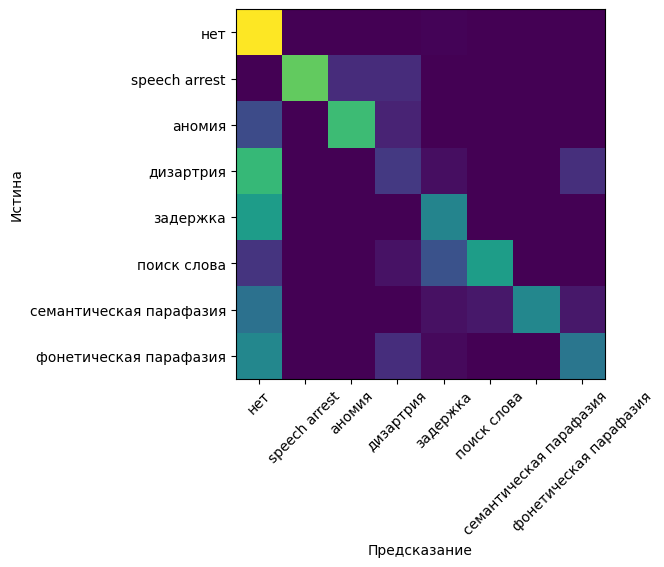

In [38]:
evaluate(catboost.CatBoostClassifier(task_type='GPU',
                                    devices='0',
                                    random_state=SEED,
                                    silent=True))


In [41]:
class OneVsOneVsNeutralClassifier(BaseEstimator):
    def __init__(self,
                 base_model: BaseEstimator,
                 meta_model: BaseEstimator,
                 column_names: Sequence[str] | None = None,
                 class_pairs_and_features_path = '../data/models/'
                                    'class_pairs_and_features.csv'):
        self.column_names = column_names or []
        self.class_pairs_and_features_all = \
                            pl.read_csv(class_pairs_and_features_path)
        self.estimators: list[BaseEstimator] = []
        self.base_model = base_model
        self.meta_model = meta_model

    def _get_base_predictions(self, X):
        predictions = np.ndarray((len(X), len(self.estimators)))
        for i, model in enumerate(self.estimators):
            # смелое предположение; но у DecisionTreeClassifier есть
            X_this = X.select(model.feature_names_in_)
            predictions[:, i] = model.predict(X_this)
        return predictions

    def fit(self, X: pl.DataFrame | np.ndarray,
                  y: pl.Series | np.ndarray = None):
        if type(X) != pl.DataFrame:
            X = pl.from_numpy(X, self.column_names)
        if type(y) != pl.Series:
            y = pl.Series(y)
        self.classes_present = y.unique()
        self.class_pairs_and_features = \
                self.class_pairs_and_features_all.filter(
                pl.col('class_1').is_in(self.classes_present.implode())
                &pl.col('class_2').is_in(self.classes_present.implode())
                )\
                .with_columns(pl.col('include_features')\
                    .map_elements(lambda x: tuple(x.split('\uE000')),
                                    return_dtype=pl.Object))
        
        self.estimators = [] # у меня есть подозрения
        for specil in self.class_pairs_and_features.iter_rows():
            class_1, class_2, include_features = specil
            y_this = y.replace_strict({class_1: 1, class_2: -1},
                                        default=0)
            self.estimators.append(clone(self.base_model))
            X_this = X.select(pl.col(*include_features))\
                     if include_features[0] else X
            self.estimators[-1].fit(X_this, y_this)
        
        self.meta_model = clone(self.meta_model)
        self.meta_model.fit(self._get_base_predictions(X), y)
        return self

    def predict(self, X):
        return self.meta_model.predict(self._get_base_predictions(X))


Класс			Precision	Recall		F1
нет                     0.95		0.99		0.97
speech arrest           0.86		0.75		0.80
аномия                  0.92		0.74		0.82
дизартрия               0.28		0.08		0.12
задержка                0.74		0.40		0.52
поиск слова             0.50		0.45		0.47
семантическая парафазия 0.51		0.41		0.46
фонетическая парафазия  0.55		0.49		0.52
По всем                 0.66		0.54		0.58


np.float64(0.5847781602138662)

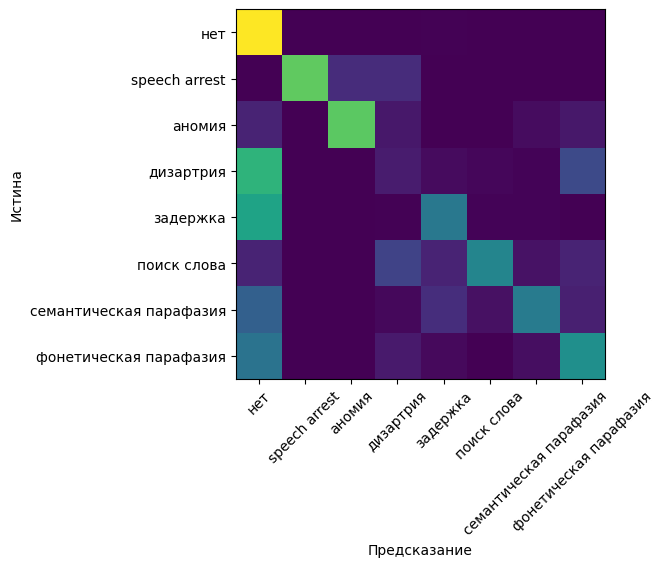

In [44]:
ovovn_classifier = OneVsOneVsNeutralClassifier(
    DecisionTreeClassifier(max_depth=6, random_state=SEED),
    DecisionTreeClassifier(random_state=SEED)
)
evaluate(ovovn_classifier)


# С транскрипцией

In [46]:
train_raw_T = pl.read_csv('../data/processed/train.csv')\
                .filter(pl.col('Response_transcription_annot')\
                        .str.len_chars() > 0)
test_raw_T = pl.read_csv('../data/processed/test.csv')\
                .filter(pl.col('Response_transcription_annot')\
                        .str.len_chars() > 0)


In [67]:
feature_extractor_T = FeatureExtractor()

In [68]:
train_X_T = feature_extractor_T.fit_transform(
    train_raw_T.drop('error_type_label'))
train_y_T = train_raw_T['error_type_label']


1202it [00:15, 77.63it/s] 


In [69]:
test_X_T = feature_extractor_T.transform(
    test_raw_T.drop('error_type_label'))
test_y_T = test_raw_T['error_type_label']


556it [00:05, 101.85it/s]


In [76]:
set(test_X_T.columns) ^ set(train_X_T.columns)

set()

Класс			Precision	Recall		F1
нет                     0.10		0.09		0.10
speech arrest           nan		0.00		0.00
аномия                  0.78		0.58		0.67
дизартрия               0.58		0.56		0.57
задержка                0.83		0.91		0.87
поиск слова             0.62		0.53		0.57
семантическая парафазия 0.53		0.39		0.45
фонетическая парафазия  0.69		0.64		0.67
По всем                 0.59		0.53		0.56


np.float64(0.555072006289383)

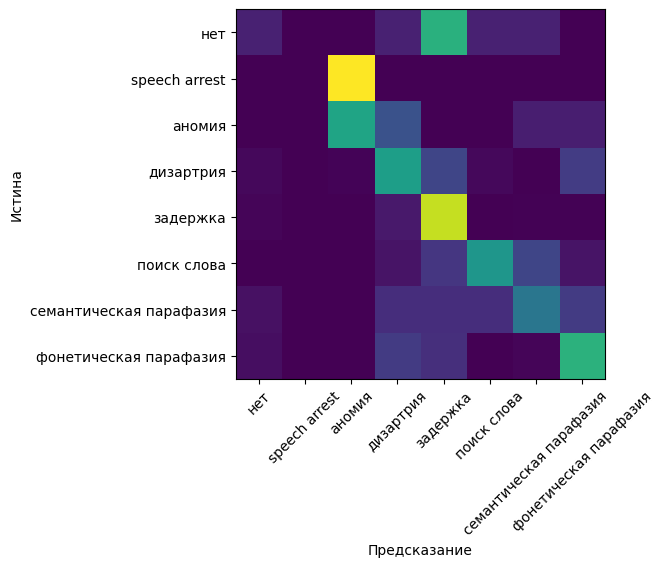

In [87]:
evaluate(DecisionTreeClassifier(max_depth=12, 
                                random_state=SEED),
                        (train_X_T, train_y_T),
                        (test_X_T, test_y_T))

Класс			Precision	Recall		F1
нет                     0.14		0.09		0.11
speech arrest           nan		0.00		0.00
аномия                  0.78		0.58		0.67
дизартрия               0.54		0.36		0.43
задержка                0.75		0.95		0.84
поиск слова             0.50		0.37		0.42
семантическая парафазия 1.00		0.30		0.47
фонетическая парафазия  0.65		0.63		0.64
По всем                 0.62		0.47		0.51


np.float64(0.510955615459664)

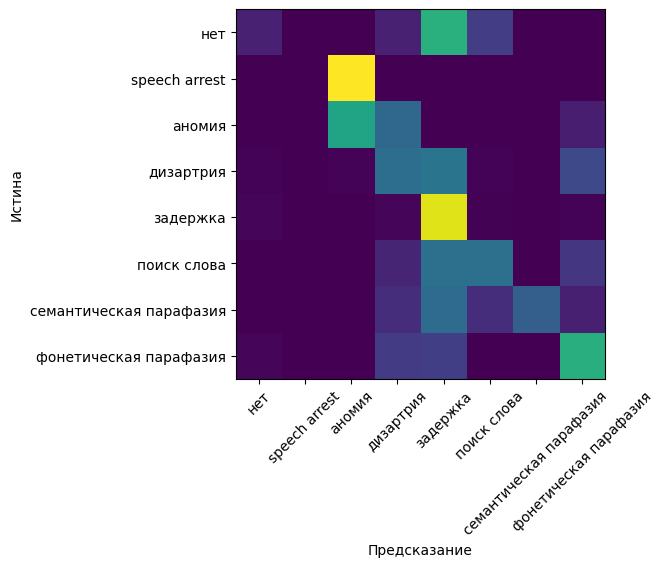

In [88]:
evaluate(RandomForestClassifier(random_state=SEED),
                        (train_X_T, train_y_T),
                        (test_X_T, test_y_T))


Класс			Precision	Recall		F1
нет                     0.00		0.00		0.00
speech arrest           nan		0.00		0.00
аномия                  0.90		0.75		0.82
дизартрия               0.73		0.58		0.65
задержка                0.83		0.97		0.89
поиск слова             0.65		0.58		0.61
семантическая парафазия 0.71		0.43		0.54
фонетическая парафазия  0.69		0.72		0.70
По всем                 0.64		0.58		0.60


np.float64(0.6016810313927831)

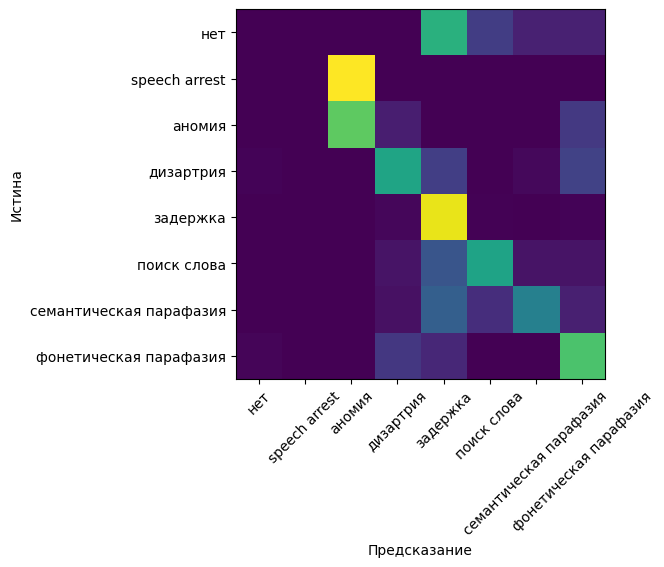

In [89]:
evaluate(catboost.CatBoostClassifier(task_type='GPU',
                                    devices='0',
                                    random_state=SEED,
                                    silent=True),
                        (train_X_T, train_y_T),
                        (test_X_T, test_y_T))


Класс			Precision	Recall		F1
нет                     0.00		0.00		0.00
speech arrest           nan		0.00		0.00
аномия                  0.91		0.83		0.87
дизартрия               0.55		0.52		0.53
задержка                0.81		0.89		0.85
поиск слова             0.47		0.42		0.44
семантическая парафазия 0.52		0.48		0.50
фонетическая парафазия  0.64		0.60		0.62
По всем                 0.56		0.53		0.55


np.float64(0.5450173829208166)

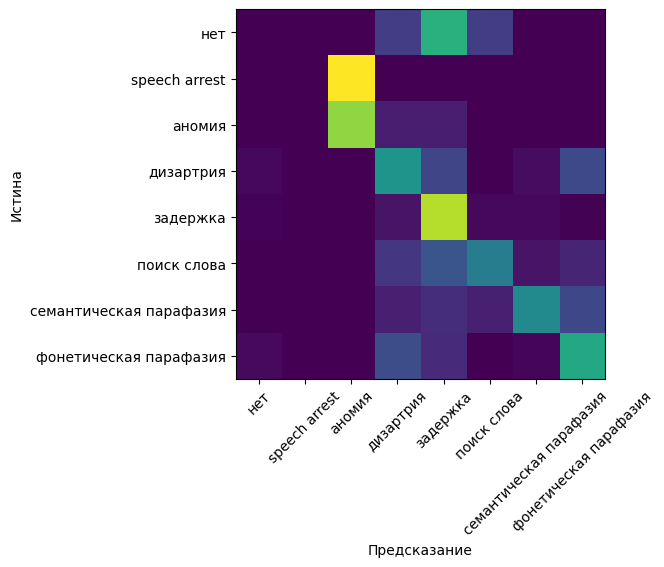

In [93]:
ovovn_classifier_T = OneVsOneVsNeutralClassifier(
    DecisionTreeClassifier(max_depth=6, random_state=SEED),
    DecisionTreeClassifier(random_state=SEED),
    class_pairs_and_features_path='../data/models/'
                'class_pairs_and_featuresT.csv'
)
evaluate(ovovn_classifier_T,
                        (train_X_T, train_y_T),
                        (test_X_T, test_y_T))
